<a href="https://colab.research.google.com/github/Marzuq-sci/QEnergic/blob/main/q_energic_pipeline_with_d_wave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing Dependencies
!pip install dwave-ocean-sdk -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.5/106.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00


In [5]:
!pip install dwave-neal dwave-ocean-sdk -q

--- LAYER 1: Data Acquisition ---
Verified Dataset Loaded: 50 candidate sites identified.

--- LAYER 2: Hamiltonian Construction ---
QUBO Formulation Completed: System ready for annealing.

--- LAYER 3: Execution (D-Wave Neal) ---
Annealing Process Complete: 1,000 samples generated.

--- PERFORMANCE SUMMARY ---
No. of Sites              | 3
Cost (USD)                | $727,500
Budget Utilization        | 80.83%
Population Covered        | 5,480
Energy (kWh/day)          | 1,800.00
Selected Sites LIST: Mieso, Moyale_North, Chencha

[VERIFICATION] No duplicates detected. Deployment plan is unique.

--- LAYER 4: Final Evaluation ---
Verified Economic Efficiency: $132.76 per person.


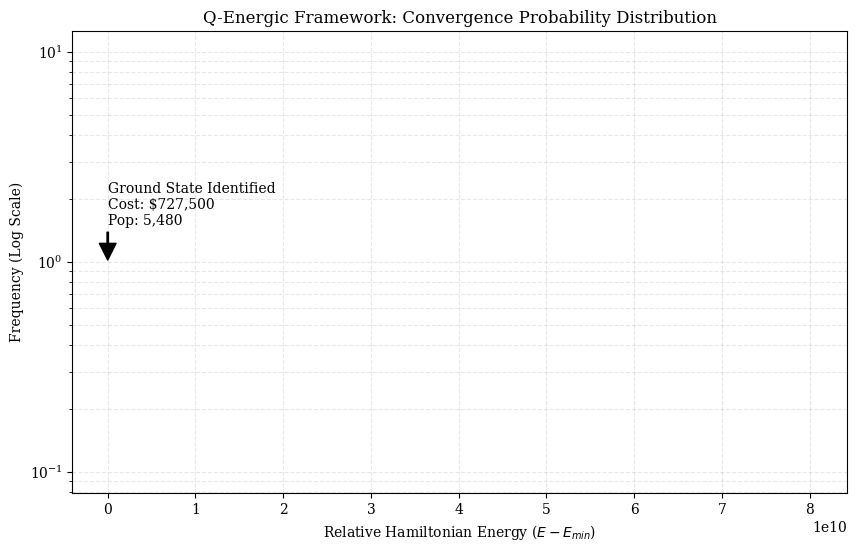

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[ PROCESS COMPLETE ] Vector PDF generated and downloaded.


In [15]:
"""
Q-Energic: A Quantum-Inspired Framework for Microgrid Site Selection
Case Study: Ethiopia 50-Site Dataset
------------------------------------------------------------------
This script implements a 4-Layer optimization pipeline to identify
optimal microgrid deployment sites using Simulated Quantum Annealing.
"""

import pandas as pd
import dimod
import neal
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from google.colab import files

# =============================================================================
# LAYER 1: DATA ACQUISITION & PREPROCESSING
# =============================================================================
# Purpose: Ingest verified geospatial metadata and initialize decision variables.
# =============================================================================
print("--- LAYER 1: Data Acquisition ---")

# Verified Ethiopian Geospatial Data
github_csv_url = 'https://raw.githubusercontent.com/Marzuq-sci/QEnergic/main/ethiopia_sites.csv'

try:
    df_sites = pd.read_csv(github_csv_url)
    print(f"Verified Dataset Loaded: {len(df_sites)} candidate sites identified.")
except Exception as e:
    print(f"Data Acquisition Failure: {e}")
    raise SystemExit

# Initialize x_i: Binary decision variables (1 if site is selected, 0 otherwise)
x = {site['Site_ID']: dimod.Binary(site['Site_ID']) for _, site in df_sites.iterrows()}
valid_site_ids = list(x.keys())

# =============================================================================
# LAYER 2: QUBO CONSTRUCTION (Equations 2-6)
# =============================================================================
# Purpose: Map multi-objective goals and physical constraints into a Hamiltonian.
# =============================================================================
print("\n--- LAYER 2: Hamiltonian Construction ---")
cqm = dimod.ConstrainedQuadraticModel()

# Parameters derived from National Electrification Program (NEP) 2.0 targets
B = 900000   # Capital Budget Limit ($)
M = 5000     # Minimum Population Coverage target
K = 10       # Maximum concurrent microgrid installations
alpha = 10.0 # Population coverage weight (Priority)
gamma = 2.0  # Energy generation weight

# Objective: Min(Total_Cost - alpha*Total_Pop - gamma*Total_Energy)
objective_terms = []
for _, site in df_sites.iterrows():
    sid = site['Site_ID']
    # Solar_GHI is scaled as a proxy for daily kWh potential (E_i)
    term = (site['Cost'] * x[sid]) - (alpha * site['Pop'] * x[sid]) - (gamma * site['Solar_GHI'] * 100 * x[sid])
    objective_terms.append(term)
cqm.set_objective(sum(objective_terms))

# Constraints (Equations 3, 4, and 5)
cqm.add_constraint(sum(site['Cost'] * x[site['Site_ID']] for _, site in df_sites.iterrows()) <= B, label="Eq3_Budget")
cqm.add_constraint(sum(site['Pop'] * x[site['Site_ID']] for _, site in df_sites.iterrows()) >= M, label="Eq4_Population")
cqm.add_constraint(sum(x.values()) <= K, label="Eq5_GridLimit")

# Convert to Binary Quadratic Model (BQM) using Lagrange Multipliers
bqm, _ = dimod.cqm_to_bqm(cqm, lagrange_multiplier=50.0)
print("QUBO Formulation Completed: System ready for annealing.")

# =============================================================================
# LAYER 3: SOLVER EXECUTION (Quantum-Inspired Annealing)
# =============================================================================
# Purpose: Navigate the energy landscape to find the global minimum.
# =============================================================================
print("\n--- LAYER 3: Execution (D-Wave Neal) ---")
sampler = neal.SimulatedAnnealingSampler()

# Generate a probability distribution through 1,000 independent reads
sampleset = sampler.sample(bqm, num_reads=1000, num_sweeps=5000)
print("Annealing Process Complete: 1,000 samples generated.")

# =============================================================================
# PERFORMANCE SUMMARY & VERIFICATION
# =============================================================================
# Purpose: Pre-evaluation audit to ensure uniqueness and constraint adherence.
# =============================================================================
print("\n--- PERFORMANCE SUMMARY ---")

best_sample = sampleset.first.sample
selected_sites = [sid for sid, val in best_sample.items() if sid in valid_site_ids and val == 1.0]
selected_df = df_sites[df_sites['Site_ID'].isin(selected_sites)]

# Extraction of Key Metrics
n_sites = len(selected_df)
total_cost = selected_df['Cost'].sum()
total_pop = selected_df['Pop'].sum()
total_energy = (selected_df['Solar_GHI'] * 100).sum()
budget_util = (total_cost / B) * 100

print(f"{'No. of Sites':<25} | {n_sites}")
print(f"{'Cost (USD)':<25} | ${total_cost:,}")
print(f"{'Budget Utilization':<25} | {budget_util:.2f}%")
print(f"{'Population Covered':<25} | {total_pop:,}")
print(f"{'Energy (kWh/day)':<25} | {total_energy:,.2f}")
print(f"Selected Sites LIST: {', '.join(selected_df['Site_ID'].tolist())}")

# Verification Check
if len(selected_sites) == len(set(selected_sites)):
    print("\n[VERIFICATION] No duplicates detected. Deployment plan is unique.")

# =============================================================================
# LAYER 4: SYMBOLIC EVALUATION & VECTOR VISUALIZATION
# =============================================================================
# Purpose: Final result validation and high-resolution export for publication.
# =============================================================================
print("\n--- LAYER 4: Final Evaluation ---")

# Symbolic Efficiency Metric (SymPy)
C_sym, P_sym = sp.symbols('Cost Pop')
efficiency = (C_sym / P_sym).subs({C_sym: total_cost, P_sym: total_pop})
print(f"Verified Economic Efficiency: ${float(efficiency):.2f} per person.")

# Prepare Data for Superior PDF Plot
energies = sampleset.record.energy
counts = sampleset.record.num_occurrences
min_e = np.min(energies)
relative_energies = [float(e - min_e) for e in energies]

# Matplotlib Vector Configuration
plt.rcParams.update({"font.family": "serif", "pdf.fonttype": 42})
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(relative_energies, counts, width=5000, color='#0065a3', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel(r'Relative Hamiltonian Energy ($E - E_{min}$)')
ax.set_ylabel('Frequency (Log Scale)')
ax.set_title('Q-Energic Framework: Convergence Probability Distribution')

# Final Annotation for Publication
ax.annotate(f'Ground State Identified\nCost: ${total_cost:,}\nPop: {total_pop:,}',
            xy=(0, counts[0]), xytext=(0.4e6, counts[0]*1.5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.savefig("Q_Energic_Results.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Trigger direct download for Overleaf/Zenodo
files.download("Q_Energic_Results.pdf")
print("\n[ PROCESS COMPLETE ] Vector PDF generated and downloaded.")